[![Open In Colab](./colab-badge.png)](https://colab.research.google.com/github/MooseNeuro/moose-notebooks/blob/main/Neuronal_modeling_by_composition.ipynb) [![Binder](./binder_logo.png)](https://mybinder.org/v2/gh/MooseNeuro/moose-notebooks/HEAD?labpath=Neuronal_modeling_by_composition.ipynb)

# Composing a neuronal model with existing components

Creating a detailed biophysical model entirely by manual coding can be tedious and error prone. Moreover, building a model from scratch using experimental data is not easy. One can reuse components from existing models to build new composite models.

As of version 4.3.0, MOOSE includes a library of voltage-gated ion channels from the [IonChannel Genealogy](https://icg.neurotheory.ox.ac.uk/) database.
It also includes a set of neuronal morphologies from published models. These can be easily used to build composite models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import moose

# Import the morphology utilities
from moose import morphologies as morph  
# Import the channel database
from moose import channels as chan

# Utility functions to plot morphology
import moose.plot_utils as mplt

print('Moose version:', moose.__version__)
if moose.exists('/model'):
    moose.delete('/model')
    
model = moose.Neutral('/model')

INFO:numexpr.utils:NumExpr defaulting to 12 threads.


Moose version: 4.3.0


## Using the morphology database included with MOOSE

You can use `morph.list()` to see the morphologies bundled with MOOSE.

In [2]:
morph.list()


Name                   Species    Cell type              Region               Source
──────────────────────────────────────────────────────────────────────────────────────────
traub91_CA3            rat        CA3 pyramidal          hippocampus CA3      Traub et al. 1991, J Neurophysiol 66:635-650
purk_eds1994_full      guinea pig Purkinje               cerebellum           De Schutter & Bower 1994, J Neurophysiol 71:375-400
gran_bhalla1991_ob     rat        granule                olfactory bulb       Bhalla & Bower 1993, J Neurophysiol 69:1948-1965
mit_bhalla1991         rat        mitral                 olfactory bulb       Bhalla & Bower 1993, J Neurophysiol 69:1948-1965
mit_davison_reduced    rat        mitral                 olfactory bulb       Davison et al. 2003, J Comput Neurosci 15:375-384
gran_migliore_olfactory rat        granule                olfactory bulb       Migliore & Shepherd 2008, PLoS Comput Biol 4:e1000011
traub2005_suppyr       rat        L2/3 pyramidal (SupPy

Let us load the CA3 pyramidal cell morphology published in [Traub et al, 1991](https://www.ncbi.nlm.nih.gov/pubmed?holding=modeldb&term=1663538). Its name in the database is `"traub91_CA3"`. This model had specific membrane resistance $1 \Omega m^2$ and specific axial resistance $1 \Omega m$.

In [3]:
result = morph.load('traub91_CA3', f'{model.path}/CA3_pyr', )

ReadSwc: /Users/subha/src/moose/moose-core/_build_install/lib/python3.13/site-packages/moose/morphologies/data/swc/traub91_CA3.swc    : NumSegs = 19, bad = 0, Validated = 1, numBranches = 3
ReadSwc::diagnostics:           :     0
ReadSwc::diagnostics:           :     1
ReadSwc::diagnostics:           :     0
ReadSwc::diagnostics:           :     8
ReadSwc::diagnostics:           :    10
ReadSwc::diagnostics:           :     0
ReadSwc::diagnostics:           :     0
ReadSwc::diagnostics:           :     0
ReadSwc::diagnostics:           :     0
ReadSwc::diagnostics:           :     0
ReadSwc::diagnostics:           :     0
ReadSwc::diagnostics:           :     0
ReadSwc::diagnostics:           :     0
ReadSwc::diagnostics:           :     0


The `morph.load(...)` function returns a `MorphologyResult` object, where the `root` attribute is the loaded `Neuron` object. The compartments are located under it.

In [4]:
moose.showfield(result.root)


[/model[0]/CA3_pyr[0]]
name                           = CA3_pyr
className                      = Neuron
tick                           = -1
dt                             = 0.0
CM                             = 0.01
Em                             = -0.065
RA                             = 1.0
RM                             = 1.0
compartmentLengthInLambdas     = 0.2
numBranches                    = 0
numCompartments                = 0
numSpines                      = 0
phi                            = 0.0
sourceFile                     = 
theta                          = 0.0



### Display the morphology
MOOSE includes a utility function to plot the morphology base on the coordinates of the compartments. We can try to display the morphology of the neuron using that.

This is not satisfactory as the model does not have real coordinate information, so the compartments are plotted over one another. In such a scenario we can plot the morphology as a graph (nodes and edges) automatically spread out in space.

<Axes: >

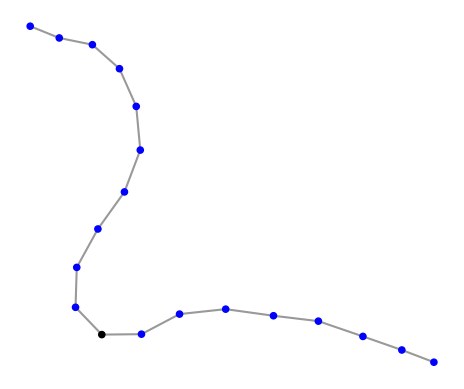

In [5]:
# We imported moose.plot_utils as mplt
mplt.plotMorphologyGraph(result.root)

Thus it is simply a linear model. We can print the paths of all the compartments in the model, too.

In [6]:
moose.le(result.root)

Elements under /model[0]/CA3_pyr[0]
    /model[0]/CA3_pyr[0]/spine
    /model[0]/CA3_pyr[0]/soma
    /model[0]/CA3_pyr[0]/basal0
    /model[0]/CA3_pyr[0]/basal0_1
    /model[0]/CA3_pyr[0]/basal0_2
    /model[0]/CA3_pyr[0]/basal0_3
    /model[0]/CA3_pyr[0]/basal0_4
    /model[0]/CA3_pyr[0]/basal0_5
    /model[0]/CA3_pyr[0]/basal0_6
    /model[0]/CA3_pyr[0]/basal0_7
    /model[0]/CA3_pyr[0]/dend0
    /model[0]/CA3_pyr[0]/dend0_1
    /model[0]/CA3_pyr[0]/dend0_2
    /model[0]/CA3_pyr[0]/dend0_3
    /model[0]/CA3_pyr[0]/dend0_4
    /model[0]/CA3_pyr[0]/dend0_5
    /model[0]/CA3_pyr[0]/dend0_6
    /model[0]/CA3_pyr[0]/dend0_7
    /model[0]/CA3_pyr[0]/dend0_8
    /model[0]/CA3_pyr[0]/dend0_9



We need to set the resting membrane potential of all the compartments low because the `naf` model can have significant window current even at the the default -60 mV, causing the neuron to slowly depolarize even at rest.

In [7]:
EL = -70e-3
result.root.Em = EL
for comp in moose.wildcardFind(f'{model.path}/##[TYPE=Compartment]'):
    comp.Em = EL
    comp.initVm = EL

## Loading channel prototypes

The builtin ICG channel database can be used for published ion channel models.

Ion channels are categorized by the ion they are permeable to. We can list the ion classes in the database. `IH` is a special class for nonspecific cation channels, and so is `KCa` for $Ca^{2+}$ dependent $K^{+}$ channels.

In [8]:
chan.list_ion_classes()

['Ca', 'IH', 'K', 'KCa', 'Na']

We can use `chan.search(...)` function to search for a channel by the name of the author of article in which the model was published, the year of publication, etc. The channels for the Traub et al 1991 model are not available in ICG database. We can try the one from Traub et al, 2003.

You will notice that the function returns a `list` of `dict`s. Each dict contains information about one channel type. Thge `modeldb_id` is the unique identifier of the corresponding model in the [ModelDB database](https://modeldb.science/). ModelDB entries correspond to publications, so a single `modeldb_id` is shared by all the ion channels  in that model. Individual ion channels get a unique `icg_id` in the ICG database.

In [9]:
chan.search(author='Traub', year=2003)


#    ModelDB ID   Year   Authors                             Channels
──────────────────────────────────────────────────────────────────────────────────────────
[0 ] 20756        2003   Traub RD, Buhl EH, Gloveli T,…      ar(IH), cal(Ca), cat(Ca), k2(K), ka(K),…



[{'modeldb_id': 20756,
  'meta': {'icg_id': '1674',
   'modeldb_id': '20756',
   'suffix': 'ar',
   'ion_class': 'IH',
   'icg_ref_id': '172',
   'authors': 'Traub RD, Buhl EH, Gloveli T, Whittington MA',
   'title': 'Fast rhythmic bursting can be induced in layer 2/3 cortical neurons by enhancing persistent Na+ conductance or by blocking BK channels.',
   'year': '2003',
   'pubmedid': '12574468',
   'citation_count': '130'},
  'channels': {'cal': [{'modeldb_id': 20756,
     'icg_id': '1676',
     'ion_class': 'Ca',
     'suffix': 'cal',
     'gbar_name': 'gbar_cal',
     'gbar_default': 1.0,
     'q10_tau': 1.0,
     'q10_g': 1.0,
     'gate_var': 'm',
     'gate_power': 2,
     'best_sm': 1,
     'sm1_fit': True,
     'sm1_err1_ss': 0.0283923380157939,
     'sm1_err1_tau': 0.025743317757173742,
     'sm2_fit': True,
     'sm2_err1_ss': 0.02119000996818533,
     'sm2_err1_tau': 0.025743317757173742,
     'sm3_fit': True,
     'sm3_err1_ss': 0.02839233801572399,
     'sm3_err1_tau': 0

Here we will only use the fast $Na^{+}$ channel `naf` (ICG ID 1684), and the delayed rectifier `kdr` (ICG ID 1682) channels. The channels submodule provide a function to create channel prototypes and distribute them across compartments (you can also call the functions `chan.make_prototype()` and `chan.insert()` for these steps one at a time).

In [10]:
naf_list = chan.load(f'{model.path}/##[TYPE=Compartment]', 
                     icg_id=1684, 
                     gbar=lambda c: morph.surface_area(c) * 800.0, Ek=50e-3)

For the `gbar` parameter one can pass a function that takes the compartment as the parameter and returns the computed `Gbar` (maximum conductance) for that comprtment. One can also pass a dict `{compartment: Gbar}` or a scalar value for this.

In [11]:
kdr_list = chan.load(f'{model.path}/##[TYPE=Compartment]', 
                     icg_id=1682, 
                     gbar=lambda c: morph.surface_area(c) * 400.0,
                     Ek=-100e-3)

You can check that these channels are indeed available inside the compartments.

In [12]:
soma = moose.element(f'{result.root.path}/soma')
moose.le(soma)

Elements under /model[0]/CA3_pyr[0]/soma[0]
    /model[0]/CA3_pyr[0]/soma[0]/naf_20756
    /model[0]/CA3_pyr[0]/soma[0]/kdr_20756



In [13]:
moose.showmsg(f'{soma.path}/naf_20756')

INCOMING:
  /model[0]/CA3_pyr[0]/soma[0]/naf_20756[0] [parentMsg] <-- /model[0]/CA3_pyr[0]/soma[0] [childOut]
  /model[0]/CA3_pyr[0]/soma[0]/naf_20756[0] [process,reinit] <-- /clock[0] [process4,reinit4]

OUTGOING:
  /model[0]/CA3_pyr[0]/soma[0]/naf_20756[0] [childOut] --> /model[0]/CA3_pyr[0]/soma[0]/naf_20756[0]/gateX[0] [parentMsg]
  /model[0]/CA3_pyr[0]/soma[0]/naf_20756[0] [childOut] --> /model[0]/CA3_pyr[0]/soma[0]/naf_20756[0]/gateY[0] [parentMsg]
  /model[0]/CA3_pyr[0]/soma[0]/naf_20756[0] [childOut] --> /model[0]/CA3_pyr[0]/soma[0]/naf_20756[0]/gateZ[0] [parentMsg]
  /model[0]/CA3_pyr[0]/soma[0]/naf_20756[0] [channelOut] --> /model[0]/CA3_pyr[0]/soma[0] [handleChannel]



## Connect a `PulseGen` for current injection

Now we can apply a current injection protocol with `moose.PulseGen` object and simulate the model.

In [14]:
pg = moose.PulseGen(f'{model.path}/pg')

moose.connect(pg, 'output', soma, 'injectMsg')

<moose.SingleMsg path=/Msgs[0]/singleMsg[56] id=5 dataIndex=56 fieldIndex=0>

## Setup tables for recording data
We can now create tables to record the membrane voltage of each compartment.

In [15]:
vmtabs = []
for comp in moose.wildcardFind(f'{result.root.path}/#[TYPE=Compartment]'):
    print(comp.path)
    tab = moose.Table(f'{model.path}/Vm_{comp.name}')
    moose.connect(tab, 'requestOut', comp, 'getVm')
    vmtabs.append(tab)

itab = moose.Table(f'{model.path}/Inject')
moose.connect(itab, 'requestOut', pg, 'getOutputValue')

/model[0]/CA3_pyr[0]/soma[0]
/model[0]/CA3_pyr[0]/basal0[0]
/model[0]/CA3_pyr[0]/basal0_1[0]
/model[0]/CA3_pyr[0]/basal0_2[0]
/model[0]/CA3_pyr[0]/basal0_3[0]
/model[0]/CA3_pyr[0]/basal0_4[0]
/model[0]/CA3_pyr[0]/basal0_5[0]
/model[0]/CA3_pyr[0]/basal0_6[0]
/model[0]/CA3_pyr[0]/basal0_7[0]
/model[0]/CA3_pyr[0]/dend0[0]
/model[0]/CA3_pyr[0]/dend0_1[0]
/model[0]/CA3_pyr[0]/dend0_2[0]
/model[0]/CA3_pyr[0]/dend0_3[0]
/model[0]/CA3_pyr[0]/dend0_4[0]
/model[0]/CA3_pyr[0]/dend0_5[0]
/model[0]/CA3_pyr[0]/dend0_6[0]
/model[0]/CA3_pyr[0]/dend0_7[0]
/model[0]/CA3_pyr[0]/dend0_8[0]
/model[0]/CA3_pyr[0]/dend0_9[0]


<moose.SingleMsg path=/Msgs[0]/singleMsg[76] id=5 dataIndex=76 fieldIndex=0>

## Configure the current injection

We specify the onset, duration and amplitude of the current to be injected into the soma by setting the appropriate attributes of the `PulseGen`.

In [16]:
pg.firstDelay = 20e-3     # Delay until the start of the first current pulse
pg.firstWidth = 100e-3    # Duration of the pulse
pg.firstLevel = 0.2e-9    # Amplitude of the pulse
pg.secondDelay = 1e9      # Delay till the second pulse - beyond the simulated time

## Setup the solver or integration time step
The passive properties of the neuron and the ion channel properties can make the numerical solution inaccurate. For good results, we need to use either a special solver, `HSolve`, or set the integration time step very small.

In [17]:
use_hsolve = True
if use_hsolve:
    solver = moose.HSolve(f'{result.root.path}/hsolve')
    # solver.dt = 2.5e-6
    solver.target = soma.path
else:
    for tick in range(32):
        moose.setClock(tick, 1e-6)

## Initialize the model and simulate it

In [18]:
moose.reinit()

simtime = 150e-3
moose.start(simtime)

## Plot the data

Text(0, 0.5, 'Voltage (mV)')

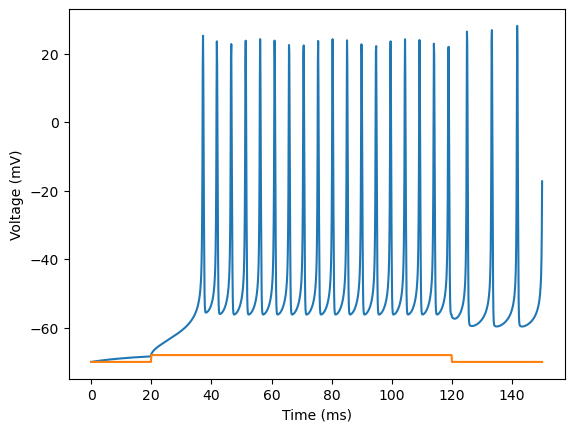

In [19]:
for tab in vmtabs:
    t = np.linspace(0, simtime, len(tab.vector))
    plt.plot(t * 1e3, tab.vector * 1e3)
    break  # Skip after plotting the Vm of a single compartment
t = np.linspace(0, simtime, len(itab.vector))
plt.plot(t * 1e3, itab.vector * 1e10 + soma.Em * 1e3)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')